In [ ]:
# !pip install numpy pandas matplotlib seaborn yfinance scikit-learn

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import requests
import io

In [58]:
# fetch nifty 500 constitutents from wikipedia along with their sectors

url = 'https://en.wikipedia.org/wiki/NIFTY_500'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(url, headers=headers)

html_content = io.StringIO(response.text)
tables = pd.read_html(html_content)

nifty500_df = tables[4]

In [9]:
'''import pandas as pd

url = 'https://en.wikipedia.org/wiki/NIFTY_500'

print("Fetching Wikipedia data...")

# 1. We let pandas handle the download, the headers, AND the filtering all in one step.
tables = pd.read_html(
    url,
    match='Symbol',  # Magically filters out all tables that don't have a "Symbol" column
    storage_options={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
)

# 2. Because we used `match='Symbol'`, the massive list of tables is reduced 
# to JUST the one we care about. So it will always be at index 0!
nifty500_df = tables[0]

print("Success! Found the Nifty 500 table.")
print(nifty500_df.head())'''

'import pandas as pd\n\nurl = \'https://en.wikipedia.org/wiki/NIFTY_500\'\n\nprint("Fetching Wikipedia data...")\n\n# 1. We let pandas handle the download, the headers, AND the filtering all in one step.\ntables = pd.read_html(\n    url,\n    match=\'Symbol\',  # Magically filters out all tables that don\'t have a "Symbol" column\n    storage_options={\'User-Agent\': \'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36\'}\n)\n\n# 2. Because we used `match=\'Symbol\'`, the massive list of tables is reduced \n# to JUST the one we care about. So it will always be at index 0!\nnifty500_df = tables[0]\n\nprint("Success! Found the Nifty 500 table.")\nprint(nifty500_df.head())'

In [59]:
header = nifty500_df.iloc[0]
nifty500_df = nifty500_df[1:]
nifty500_df.columns = header
nifty500_df = nifty500_df.reset_index(drop=True)


In [61]:
display(nifty500_df['Industry'].value_counts())

,count
Industry,
Financial Services,92
Capital Goods,61
Healthcare,46
Chemicals,34
Automobile and Auto Components,33
Fast Moving Consumer Goods,31
Information Technology,25
Consumer Durables,25
Consumer Services,25


In [64]:
tickers = nifty500_df['Symbol'].astype('str') + '.NS'
ticker_list = tickers.tolist()

In [65]:
# get raw OHLC data from yfinance

raw_data = yf.download(ticker_list, period='5y', interval='1wk')

/tmp/ipykernel_65310/2436098472.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(ticker_list, period='5y', interval='1wk')
[*********************100%***********************]  500 of 500 completed
ERROR:yfinance:
6 Failed downloads:
ERROR:yfinance:['ISEC.NS', 'PEL.NS', 'SWANENERGY.NS', 'TATAMOTORS.NS', 'SUVENPHAR.NS', 'GMRINFRASTRUCT.NS']: YFPricesMissingError('possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")')


In [66]:
closing_prices = raw_data['Close']

In [70]:
closing_prices = closing_prices.dropna(axis=1)

In [72]:
log_returns = np.log(closing_prices/closing_prices.shift(1)).dropna()

In [73]:
log_returns.describe()

Ticker,360ONE.NS,3MINDIA.NS,AARTIIND.NS,AAVAS.NS,ABB.NS,ABBOTINDIA.NS,ABCAPITAL.NS,ABFRL.NS,ABREL.NS,ACC.NS,...,WELCORP.NS,WELSPUNLIV.NS,WESTLIFE.NS,WHIRLPOOL.NS,WIPRO.NS,YESBANK.NS,ZEEL.NS,ZENSARTECH.NS,ZFCVINDIA.NS,ZYDUSLIFE.NS
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,...,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,0.005202,0.000868,-0.001943,-0.002391,0.006276,0.002366,0.004024,-0.004068,0.004130,-0.000919,...,0.007713,0.001666,0.000499,-0.003582,-0.000217,0.001029,-0.003106,0.003039,0.003182,0.002262
std,0.047053,0.038602,0.046783,0.044683,0.045886,0.031597,0.045165,0.083976,0.058942,0.038790,...,0.062946,0.058587,0.041871,0.045251,0.036141,0.053925,0.063012,0.050077,0.042071,0.034553
min,-0.150167,-0.101256,-0.215606,-0.129504,-0.155033,-0.082563,-0.124529,-1.144413,-0.171515,-0.225657,...,-0.171761,-0.170756,-0.162578,-0.320627,-0.128909,-0.194662,-0.364609,-0.133827,-0.145950,-0.097440
25%,-0.020785,-0.022727,-0.028070,-0.029111,-0.019249,-0.013516,-0.024399,-0.027744,-0.031949,-0.025060,...,-0.031557,-0.031058,-0.026004,-0.023740,-0.021523,-0.026931,-0.036523,-0.030923,-0.019188,-0.018463
50%,0.003630,-0.000698,-0.001529,-0.002171,0.001962,-0.001088,0.000991,-0.000615,0.004004,-0.000009,...,0.008035,-0.000320,-0.001112,-0.002311,0.003113,-0.002890,-0.004714,0.000607,0.002806,0.001821
75%,0.036469,0.018369,0.027850,0.022676,0.029389,0.018206,0.029742,0.027623,0.032202,0.024443,...,0.041512,0.035401,0.025687,0.019628,0.023911,0.022661,0.026883,0.032198,0.024771,0.023233
max,0.157165,0.192436,0.173538,0.194766,0.175496,0.140557,0.154965,0.148241,0.194907,0.117792,...,0.318505,0.168544,0.125374,0.168691,0.126904,0.281333,0.333541,0.156682,0.250618,0.116906


In [77]:
# scale the data
scaled_log_returns = StandardScaler().fit_transform(log_returns)
scaled_log_returns_df = pd.DataFrame(scaled_log_returns)

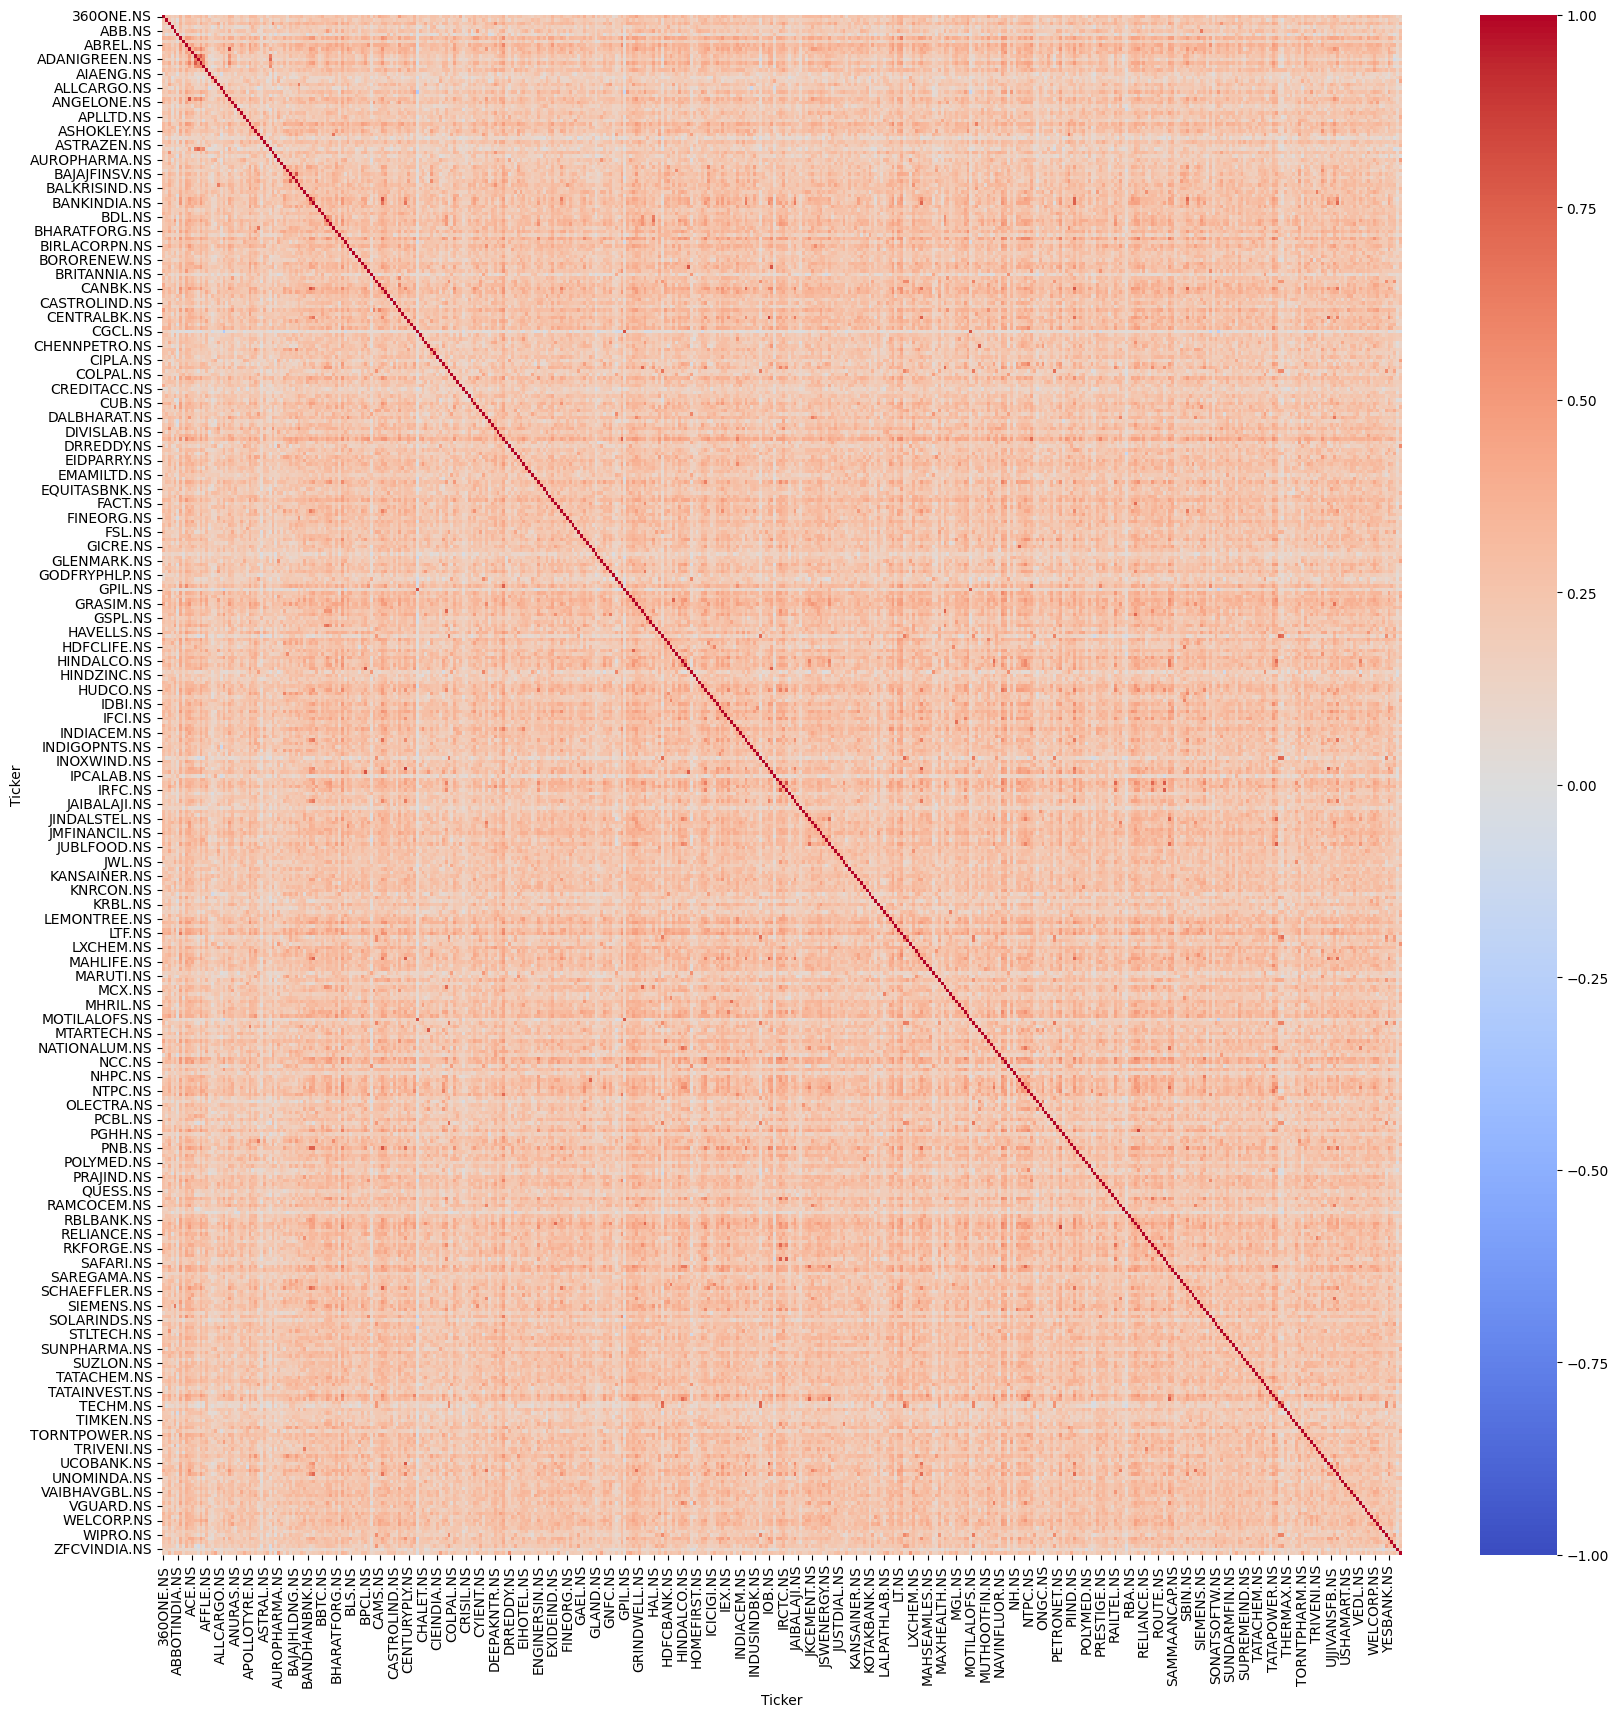

In [80]:
# heatmap of the correlation matrix

corr_matrix = log_returns.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [81]:
pca = PCA(n_components=10)

pca.fit(scaled_log_returns)

PCA(n_components=10)

In [82]:
pca.explained_variance_ratio_

array([0.25291215, 0.02954665, 0.0211654 , 0.01696033, 0.01512   ,
       0.01386329, 0.01287429, 0.01128462, 0.01093352, 0.01037355])

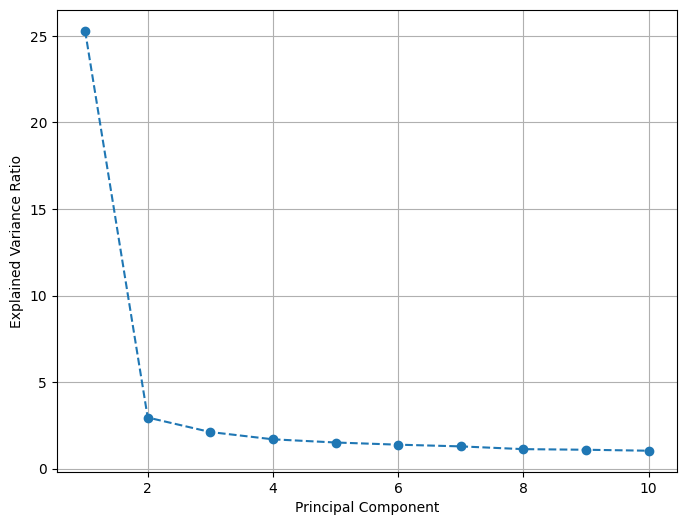

In [84]:
plt.figure(figsize=(8, 6))
plt.plot(range(1,11), pca.explained_variance_ratio_*100, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [85]:
industry_map = (
    nifty500_df[['Symbol', 'Industry']].drop_duplicates('Symbol').set_index('Symbol')['Industry']
)

### Analysis of principal components

In [88]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_df['Industry'] = pc1_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)
display(pc1_sorted.head(20)['Industry'].value_counts())
display(pc1_sorted.tail(20)['Industry'].value_counts())

,count
Industry,
Financial Services,9
Construction,2
Capital Goods,2
Realty,1
Chemicals,1
Power,1
Metals & Mining,1
Forest Materials,1
Automobile and Auto Components,1


,count
Industry,
Healthcare,7
Fast Moving Consumer Goods,3
Financial Services,3
Information Technology,3
Oil Gas & Consumable Fuels,1
Capital Goods,1
Textiles,1
Automobile and Auto Components,1


In [89]:
pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_df['Industry'] = (pc2_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map))

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc2_sorted.head(20)['Industry'].value_counts())
display(pc2_sorted.tail(20)['Industry'].value_counts())

,count
Industry,
Fast Moving Consumer Goods,7
Information Technology,6
Consumer Durables,2
Consumer Services,2
Financial Services,1
Chemicals,1
Healthcare,1


,count
Industry,
Financial Services,11
Construction,3
Oil Gas & Consumable Fuels,2
Power,2
Telecommunication,1
Metals & Mining,1


In [90]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_df['Industry'] = (pc3_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map))

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)

display(pc3_sorted.head(20)['Industry'].value_counts())
display(pc3_sorted.tail(20)['Industry'].value_counts())

,count
Industry,
Information Technology,17
Services,2
Healthcare,1


,count
Industry,
Financial Services,13
Fast Moving Consumer Goods,3
Automobile and Auto Components,2
Power,1
Capital Goods,1


In [91]:
pc4_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[3] * 100
})

pc4_df['Industry'] = (pc4_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map))

pc4_sorted = pc4_df.sort_values(by='Weight', ascending=False)
display(pc4_sorted.head(20)['Industry'].value_counts())
display(pc4_sorted.tail(20)['Industry'].value_counts())

,count
Industry,
Information Technology,11
Financial Services,8
Metals & Mining,1


,count
Industry,
Healthcare,11
Fast Moving Consumer Goods,4
Chemicals,2
Textiles,1
Capital Goods,1
Consumer Durables,1


In [92]:
pc5_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[4] * 100
})

pc5_df['Industry'] = (pc5_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map))

pc5_sorted = pc5_df.sort_values(by='Weight', ascending=False)
display(pc5_sorted.head(20)['Industry'].value_counts())
display(pc5_sorted.tail(20)['Industry'].value_counts())

,count
Industry,
Healthcare,12
Oil Gas & Consumable Fuels,5
Information Technology,2
Financial Services,1


,count
Industry,
Consumer Durables,4
Chemicals,4
Consumer Services,3
Capital Goods,2
Financial Services,2
Textiles,2
Diversified,1
Fast Moving Consumer Goods,1
Automobile and Auto Components,1
